# 🌍 CO₂ Emissions & Economic Growth — EDA & Hypothesis Testing

**Author:** `Irene Fafián`  
**Date:** `[DATE]`  
**Branch:** `irene`

---
## Business Case

A coalition of environmental researchers is tracking whether the Paris Agreement has delivered measurable results. Using country-level data from 2014 to 2020, they investigate whether economic growth and carbon emissions are genuinely decoupling  or, whether wealthy nations are simply exporting their footprint. The findings aim to hold regional climate commitments accountable with data.

### Hypothesis 1

> **Has the CO₂ intensity of GDP (co2 / GDP) declined across regions from 2014 to 2020 — and does the answer change depending on how we measure emissions?**

This is tested in two scenarios: Scenario A uses fossil and industrial emissions only (co2 / GDP, the optimistic view); Scenario B adds land-use change (co2_luc / GDP, the honest view). If decoupling holds in Scenario A but weakens in Scenario B, it suggests wealthier regions have shifted emissions rather than eliminated them.

### Hypothesis 2

> **Where renewable energy adoption has grown, has CO₂ intensity actually fallen — and where is the gap largest?**

Following Hypothesis 1, we ask why intensity declined (or didn't). Then compare annual changes in CO₂ intensity (d_co2_int) against annual changes in renewable consumption share (d_renew_share), and crucially distinguish between what a country produces (prct_renew_prod) versus what it actually consumes (prct_renew_cons) — since producing clean energy and exporting it while still burning fossil fuels domestically is not decoupling.


### Hypothesis 3

> **Do high CO₂ emissions always reflect development and improved living standards, or can they coexist with energy poverty?**

This hypothesis explores whether carbon emissions translate into domestic welfare. In theory, countries with higher gdp_per_cap should also show higher prct_access_elec, because economic development is usually associated with stronger infrastructure and near-universal electricity access. The first part of the analysis tests this expected wealth-access relationship across regions and GDP groups.

The deeper question is whether some countries generate high total co2 emissions while still having incomplete electricity access. If a country emits heavily but a significant share of its population lacks electricity, those emissions may be linked more to industrial production, extraction, manufacturing, or export-oriented activity than to broad improvements in living standards. This does not prove that a country is “polluting on behalf of others,” but it identifies cases where that possibility deserves further investigation.

**Metrics:**
- `gdp_per_cap` vs `prct_access_elec` → Tests whether richer countries and regions tend to have better electricity access.
- `gdp_group` vs `prct_access_elec` → Compares poor, middle-income, and rich countries to see whether development is associated with higher access, total emissions, and personal carbon footprints.
- `co2` (total, not per capita) vs `prct_access_elec` → Identifies countries with high total emissions but below-median electricity access.
- `co2_per_cap` as a control → Helps distinguish between countries where emissions are high because individuals consume a lot, and countries where total emissions are high mainly because of population size or industrial scale.

> If countries with low or middle gdp_per_cap and below-median prct_access_elec still show significant total co2, then emissions are not necessarily translating into universal energy access.
> If `co2_per_cap` emains relatively low in those same countries, the pattern suggests that the carbon burden is spread across a large population that may not be receiving proportional welfare benefits.

---

## Notebook Purpose

This notebook performs:
1. **Exploratory Data Analysis (EDA)** — structure, distributions, regional patterns
2. **XXX Analysis** — computing the XXX per country, region (TBD)
3. **Hypothesis Testing** — statistical validation of the decoupling claim
4. **Visualisation** — all figures saved to `../figures/`

**Input:** `../data/clean/merged_final.csv` (produced by the merge notebook)  
**Output:** Plots saved to `../figures/`, findings summarised in final markdown cell

---
## 0. Setup & Configuration

All paths and parameters are loaded from `config.yaml` to keep the notebook reproducible and environment-independent.  
Helper functions are imported from `functions.py` to keep this notebook clean and modular.

In [ ]:
from scipy import stats

In [1]:
# libraries
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sys
from pathlib import Path
import logging

# Local helpers
sys.path.append(str(Path.cwd()))  # ensures functions.py is importable
#import functions as fn

# ── Logging ──────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)

# ── Config ────────────────────────────────────────────────────────────────────
CONFIG_PATH = Path("..") / "cfg.yaml"

try:
    with open(CONFIG_PATH, "r") as file:
        cfg = yaml.safe_load(file)
except:
    print("Yaml configuration file not found!")

DATA_PATH   = Path("..") / cfg["output_data"]["df3"] 
FIGURES_DIR = Path("..") / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 120

logger.info("Setup complete. Data path: %s", DATA_PATH)

17:08:17 | INFO | Setup complete. Data path: ../../data/clean/final_df.csv


---
## 1. Load Data

Loading the merged, cleaned dataset produced by the team merge notebook.  
We immediately validate shape, dtypes, and expected columns before proceeding.

In [2]:
#importing the data as dataframe

df=pd.read_csv(cfg['output_data']['df3'])

In [3]:
# ── Quick data quality check ──────────────────────────────────────────────────
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())

Shape: (1323, 13)

Dtypes:
country                 str
year                  int64
prct_access_elec    float64
prct_renew_prod     float64
renew_prod_kwh      float64
prct_renew_cons     float64
co2                 float64
co2_luc             float64
prim_ener_cons      float64
region                  str
GDP                 float64
population          float64
gdp_per_cap         float64
dtype: object

Null counts:
country             0
year                0
prct_access_elec    0
prct_renew_prod     0
renew_prod_kwh      0
prct_renew_cons     0
co2                 0
co2_luc             0
prim_ener_cons      0
region              0
GDP                 0
population          0
gdp_per_cap         0
dtype: int64


In [4]:
df.year.value_counts()

year
2014    189
2015    189
2016    189
2017    189
2018    189
2019    189
2020    189
Name: count, dtype: int64

**Checkpoint:** Confirm the following before proceeding:
- [ ] Year range is 2014–2020
- [ ] Regional aggregates are absent (only sovereign countries)
- [ ] Key columns present: `country`, `year`, `co2_per_capita`, `gdp_per_capita`, `region`

---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Basic descriptive stats

Understanding the shape and spread of key numeric variables and creating the new necessary ones:'co2_per_cap' and 'welfare_ratio'.


In [7]:
# Basic descriptive stats
display(df.describe())


,year,prct_access_elec,prct_renew_prod,renew_prod_kwh,prct_renew_cons,co2,co2_luc,prim_ener_cons,GDP,population,gdp_per_cap
count,1323.000000,1323.000000,1323.000000,1.323000e+03,1323.000000,1323.000000,1323.000000,1323.000000,1.323000e+03,1.323000e+03,1323.000000
mean,2017.000000,82.406727,7.829568,1.149253e+10,32.142404,182.111598,215.429390,817.893875,4.312481e+11,4.021159e+07,13246.258540
std,2.000756,27.008967,12.126038,5.331230e+10,28.375302,862.696447,873.395396,3447.959414,1.798742e+12,1.467773e+08,18795.325909
min,2014.000000,4.200000,-27.502176,-1.305034e+10,0.000000,0.007328,-1.637588,0.000000,3.619381e+07,1.039900e+04,250.544732
25%,2015.000000,68.400000,0.409629,9.415000e+06,9.200000,2.963926,7.470738,13.607202,1.056854e+10,2.229652e+06,1860.258610
50%,2017.000000,99.300000,3.404211,1.774800e+08,23.900000,13.256576,33.862053,60.388885,3.621137e+10,9.063122e+06,5472.688213
75%,2019.000000,100.000000,10.899505,2.724290e+09,50.700000,67.385311,102.667156,401.554688,2.131639e+11,2.910086e+07,15601.496998
max,2020.000000,100.000000,81.557609,8.278254e+11,97.000000,10896.520508,10632.836914,41493.890625,2.154000e+13,1.426106e+09,123687.595429


In [8]:
# Creating columns with new necessary numeric variables for analysis of H3:
df['co2_per_cap'] = (df['co2'] * 1_000_000) / df['population']
df['welfare_ratio'] = df['co2_per_cap'] / (df['prct_access_elec'] / 100)

In [9]:
# Initial study by country of the top and bottom 10 countries by co2 per capita and percentage of access to electricity:
country_avg = df.groupby('country')[['co2_per_cap', 'prct_access_elec']].mean().round(2)

top10_co2    = country_avg.sort_values('co2_per_cap', ascending=False).head(10)
bottom10_co2 = country_avg.sort_values('co2_per_cap', ascending=True).head(10)

top10_elec    = country_avg.sort_values('prct_access_elec', ascending=False).head(10)
bottom10_elec = country_avg.sort_values('prct_access_elec', ascending=True).head(10)

print("Top 10 CO2 per capita:\n", top10_co2)
print("\nBottom 10 CO2 per capita:\n", bottom10_co2)
print("\nTop 10 Electricity Access:\n", top10_elec)
print("\nBottom 10 Electricity Access:\n", bottom10_elec)

Top 10 CO2 per capita:
                       co2_per_cap  prct_access_elec
country                                            
Qatar                       37.64            100.00
Trinidad and Tobago         28.43            100.00
United Arab Emirates        23.55            100.00
Bahrain                     23.44            100.00
Kuwait                      23.23            100.00
Saudi Arabia                21.23             99.97
Brunei                      20.69            100.00
Australia                   16.46            100.00
Kazakhstan                  16.33            100.00
United States               15.78            100.00

Bottom 10 CO2 per capita:
                               co2_per_cap  prct_access_elec
country                                                    
Democratic Republic of Congo         0.04             17.61
Central African Republic             0.05             13.79
Burundi                              0.05              8.73
Somalia                 

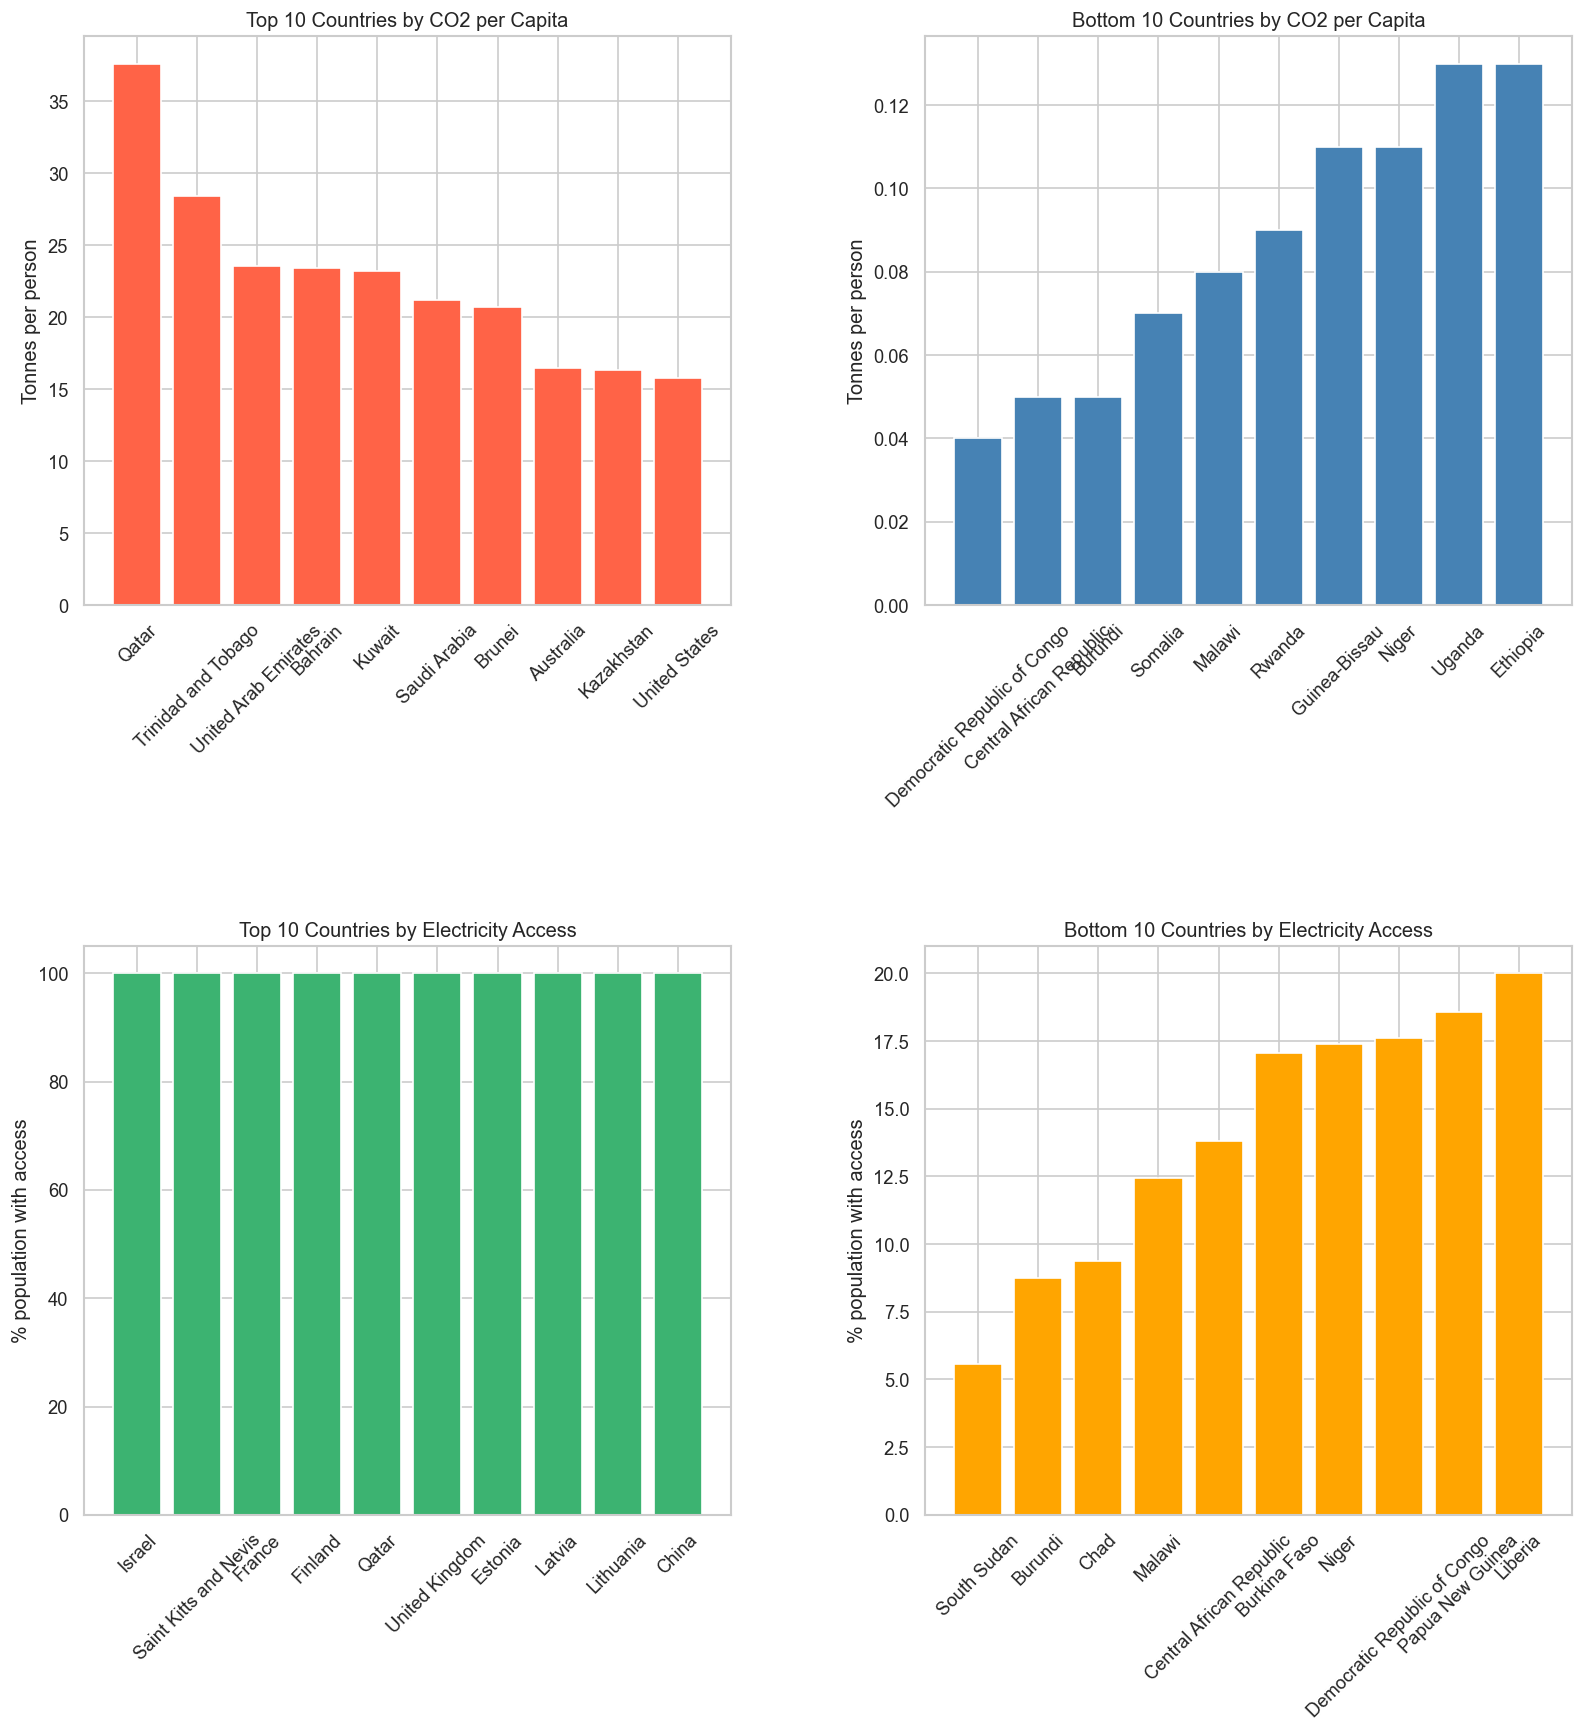

In [10]:
# ── Bar charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
plt.subplots_adjust(hspace=0.6, wspace=0.3)

# Top 10 CO2 per capita
axes[0, 0].bar(top10_co2.index, top10_co2['co2_per_cap'], color='tomato')
axes[0, 0].set_title('Top 10 Countries by CO2 per Capita')
axes[0, 0].set_ylabel('Tonnes per person')
axes[0, 0].tick_params(axis='x', rotation=45)

# Bottom 10 CO2 per capita
axes[0, 1].bar(bottom10_co2.index, bottom10_co2['co2_per_cap'], color='steelblue')
axes[0, 1].set_title('Bottom 10 Countries by CO2 per Capita')
axes[0, 1].set_ylabel('Tonnes per person')
axes[0, 1].tick_params(axis='x', rotation=45)

# Top 10 Electricity Access
axes[1, 0].bar(top10_elec.index, top10_elec['prct_access_elec'], color='mediumseagreen')
axes[1, 0].set_title('Top 10 Countries by Electricity Access')
axes[1, 0].set_ylabel('% population with access')
axes[1, 0].tick_params(axis='x', rotation=45)

# Bottom 10 Electricity Access
axes[1, 1].bar(bottom10_elec.index, bottom10_elec['prct_access_elec'], color='orange')
axes[1, 1].set_title('Bottom 10 Countries by Electricity Access')
axes[1, 1].set_ylabel('% population with access')
axes[1, 1].tick_params(axis='x', rotation=45)


### 2.2 Regional welfare ratio averages (all years included)

Sorting by welfare_ratio ascending will show which regions get the least benefit per unit of CO₂.

In [11]:
# Average values per region across the full 2014–2020 period
h3_region = df.groupby('region')[['co2_per_cap', 'prct_access_elec', 'welfare_ratio']].mean().round(2)
print(h3_region.sort_values('welfare_ratio', ascending=False))

               co2_per_cap  prct_access_elec  welfare_ratio
region                                                     
Asia                  6.85             94.41           6.96
Europe                6.52             99.86           6.53
North America         4.91             94.67           4.98
Oceania               3.08             82.94           3.47
South America         2.82             97.49           2.89
Africa                1.31             50.92           2.29


### Issues with the ratio: 
The ratio of CO₂ emissions per capita divided by electricity access has several interpretive limitations. 
Because electricity access is measured as a percentage that approaches 100% in many countries, 
the indicator eventually becomes dominated by CO₂ emissions alone, reducing its analytical value. 
In addition, low values can represent either sustainable low-carbon development or simply low levels of industrialization, 
making cross-country comparisons potentially misleading.

### 2.3. GDP per Capita vs Electricity Access by Region

Confirms the expected relationship between wealth and electricity access, and identifies which regions deviate from it.

In [12]:
# GDP per cap vs electricity access by region 
df.groupby('region')[['gdp_per_cap', 'prct_access_elec']].mean().round(2).sort_values('gdp_per_cap', ascending=False)

,gdp_per_cap,prct_access_elec
region,,
Europe,30931.43,99.86
North America,14152.97,94.67
Asia,11873.56,94.41
Oceania,11716.00,82.94
South America,8607.92,97.49
Africa,2524.05,50.92


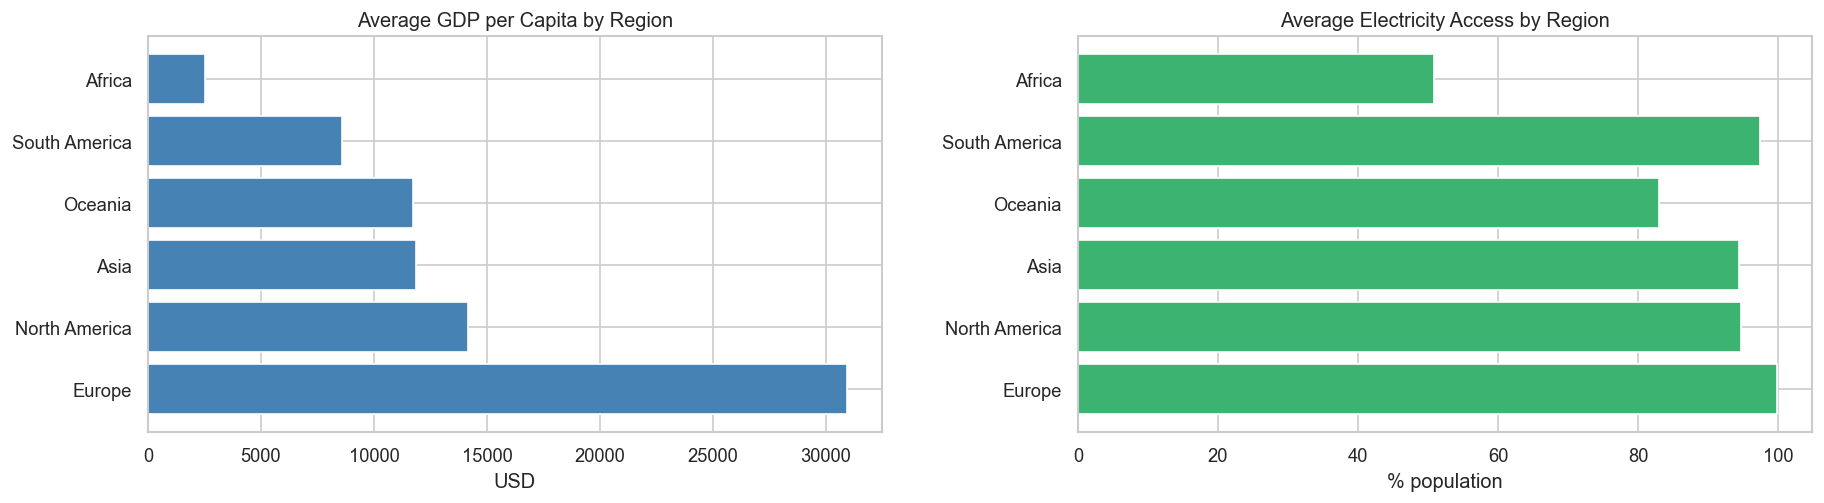

In [13]:
region_avg = df.groupby('region')[['gdp_per_cap', 'prct_access_elec']].mean().round(2).sort_values('gdp_per_cap', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(region_avg.index, region_avg['gdp_per_cap'], color='steelblue')
axes[0].set_title('Average GDP per Capita by Region')
axes[0].set_xlabel('USD')

axes[1].barh(region_avg.index, region_avg['prct_access_elec'], color='mediumseagreen')
axes[1].set_title('Average Electricity Access by Region')
axes[1].set_xlabel('% population')

plt.tight_layout(pad=3.0)
# plt.savefig(FIGURES_DIR / 'h3_gdp_vs_access_region.png', dpi=150, bbox_inches='tight')
plt.show()

** CONCLUSION: relationship confirmed **
Richer regions have better electricity access. The relationship is clean and consistent across all six regions with no exceptions.

### 2.4. Wealth Groups vs Electricity Access and CO₂ Emissions

Splits countries into four GDP per capita quartiles to test whether the poorest nations show low electricity access despite non-trivial total CO₂ emissions.

In [14]:
# Split into GDP wealth groups and check access AND total co2
df['gdp_group'] = pd.qcut(df['gdp_per_cap'], q=4, labels=['Q1_poorest', 'Q2', 'Q3', 'Q4_richest'])
df.groupby('gdp_group')[['prct_access_elec', 'co2', 'co2_per_cap']].mean().round(2)

,prct_access_elec,co2,co2_per_cap
gdp_group,,,
Q1_poorest,47.88,32.52,0.63
Q2,85.78,89.11,1.93
Q3,96.07,344.38,4.67
Q4_richest,99.94,262.92,10.51


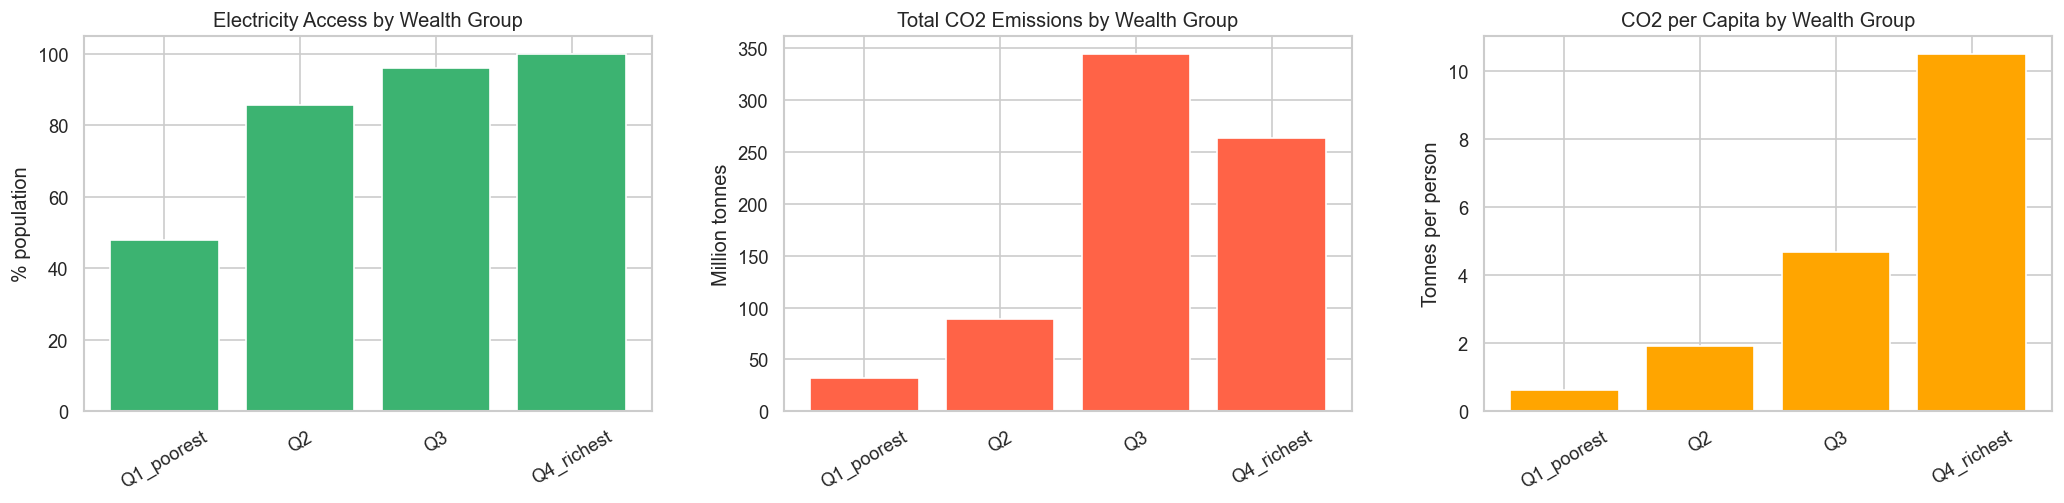

In [15]:
gdp_group_avg = df.groupby('gdp_group')[['prct_access_elec', 'co2', 'co2_per_cap']].mean().round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(gdp_group_avg.index, gdp_group_avg['prct_access_elec'], color='mediumseagreen')
axes[0].set_title('Electricity Access by Wealth Group')
axes[0].set_ylabel('% population')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(gdp_group_avg.index, gdp_group_avg['co2'], color='tomato')
axes[1].set_title('Total CO2 Emissions by Wealth Group')
axes[1].set_ylabel('Million tonnes')
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(gdp_group_avg.index, gdp_group_avg['co2_per_cap'], color='orange')
axes[2].set_title('CO2 per Capita by Wealth Group')
axes[2].set_ylabel('Tonnes per person')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout(pad=3.0)
# plt.savefig(FIGURES_DIR / 'h3_wealth_groups.png', dpi=150, bbox_inches='tight')
plt.show()

CONCLUSION: poorer countries have less electricity access but also emit less in total. The middle-income group (Q3) is the most interesting: they emit the most in absolute terms, more than the richest countries, suggesting they are in peak industrialisation. The richest countries emit the most per person but not the most in total.

### 2.5. Identify the High-Emissions, Low-Access Countries

Filters for countries with above-median total CO₂ and below-median electricity access — revealing which nations are generating significant carbon output without their populations benefiting from it.

In [16]:
# only for comparison:
mean_access = df['prct_access_elec'].mean()
median_access = df['prct_access_elec'].median()

print('Mean access to electricity:', mean_access)
print('Median access to electricity:', median_access)

mean_co2pc = df['co2_per_cap'].mean()
median_co2pc = df['co2_per_cap'].median()

print('Mean C02 emissions per capita:', mean_co2pc)
print('Median C02 emissions per capita:', median_co2pc)

Mean access to electricity: 82.40672713529857
Median access to electricity: 99.3
Mean C02 emissions per capita: 4.434363540365752
Median C02 emissions per capita: 2.480147736898512


In [17]:
# Find the outliers: below median access to electricity AND above median C02 emissions
low_access = df['prct_access_elec'] < df['prct_access_elec'].median()
high_co2_total = df['co2'] > df['co2'].median()
df[low_access & high_co2_total].groupby('country')[['gdp_per_cap', 'co2', 'co2_per_cap', 'prct_access_elec']].mean().round(2).sort_values('co2', ascending=False).head(15)

,gdp_per_cap,co2,co2_per_cap,prct_access_elec
country,,,,
India,1826.24,2398.18,1.76,91.80
Russia,9383.41,1635.24,11.25,95.50
Indonesia,3695.89,580.55,2.17,97.80
Mexico,10706.31,481.74,4.00,99.10
South Africa,6321.74,456.57,7.88,85.60
Vietnam,2640.72,200.54,2.16,99.20
Pakistan,1359.17,184.89,0.82,92.49
Venezuela,8082.73,139.09,4.55,99.20
Iraq,6249.39,137.51,3.76,99.20


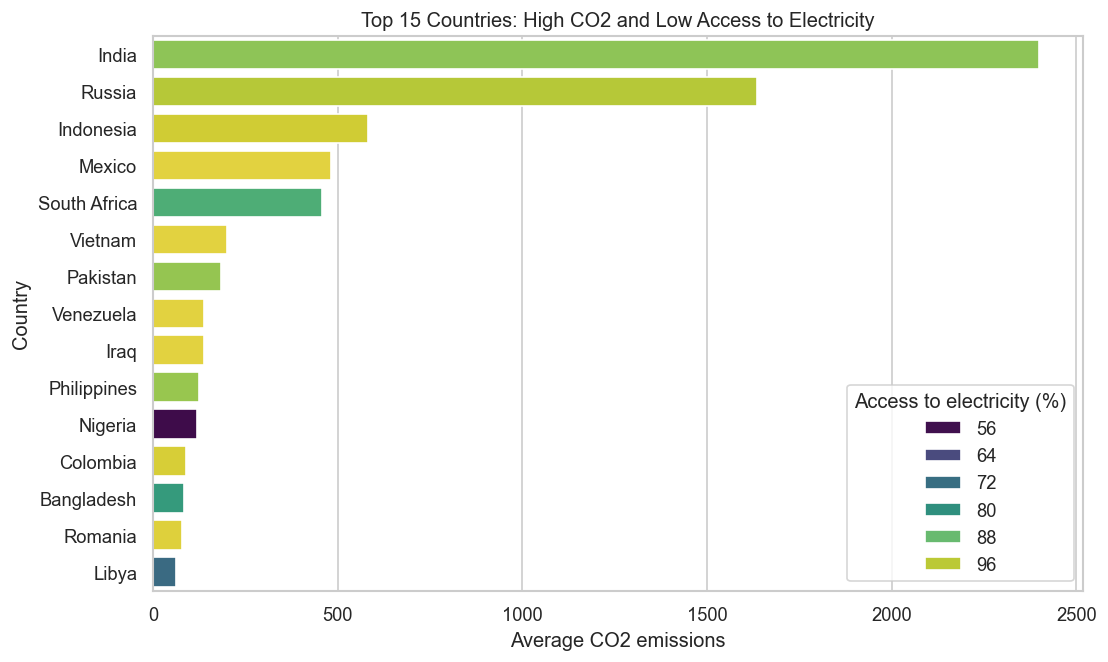

In [18]:
# Outliers output:
outliers = (df[low_access & high_co2_total].groupby('country')[['gdp_per_cap', 'co2', 'co2_per_cap', 'prct_access_elec']].mean().round(2).sort_values('co2', ascending=False).head(15).reset_index())
plt.figure(figsize=(10, 6))

sns.barplot(
    data=outliers,
    y='country',
    x='co2',
    hue='prct_access_elec',
    palette='viridis')

plt.title('Top 15 Countries: High CO2 and Low Access to Electricity')
plt.xlabel('Average CO2 emissions')
plt.ylabel('Country')
plt.legend(title='Access to electricity (%)')
plt.savefig(FIGURES_DIR / 'top15_highC02_low_access.png', dpi=150, bbox_inches='tight')
plt.show()

CONCLUSION: Some countries emit significant amounts of CO₂ in total while a large share of their population still lacks electricity access. India, Russia, Nigeria and Indonesia are the clearest examples, their emissions are not translating into universal energy access for their own people.

---
## 3. Deeper Analysis

### 3.1 Correlation Between Key Variables

Computing pairwise correlations between the core H3 variables to quantify the relationships observed in the EDA.


In [19]:
# Correlation matrix for H3 variables
corr_cols = ['gdp_per_cap', 'prct_access_elec', 'co2', 'co2_per_cap']
corr_matrix = df[corr_cols].corr().round(2)
print(corr_matrix)

                  gdp_per_cap  prct_access_elec   co2  co2_per_cap
gdp_per_cap               1.0              0.40  0.10         0.60
prct_access_elec          0.4              1.00  0.12         0.41
co2                       0.1              0.12  1.00         0.16
co2_per_cap               0.6              0.41  0.16         1.00


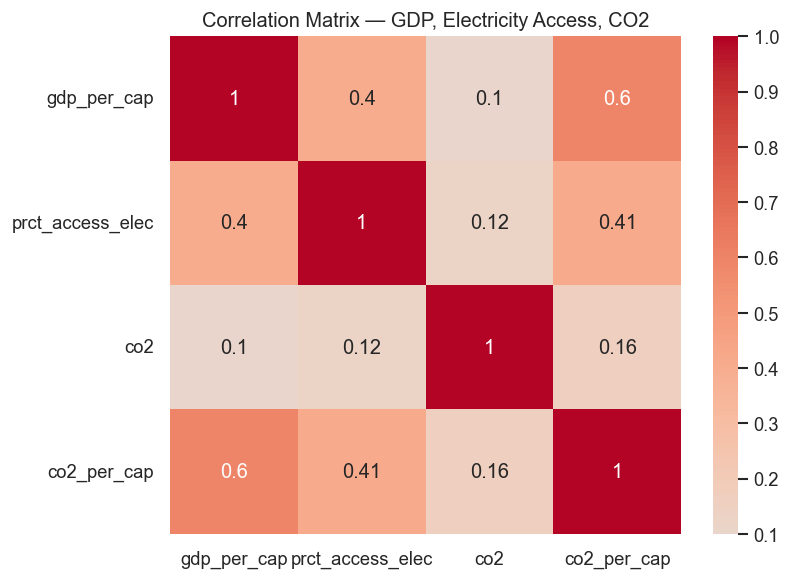

In [20]:
# Visualise as heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix — GDP, Electricity Access, CO2')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'h3_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Evolution of Electricity Access by Region Over Time

Tracking whether electricity access has improved across regions during 2014–2020 — and whether the gap between Africa and the rest is closing or holding.

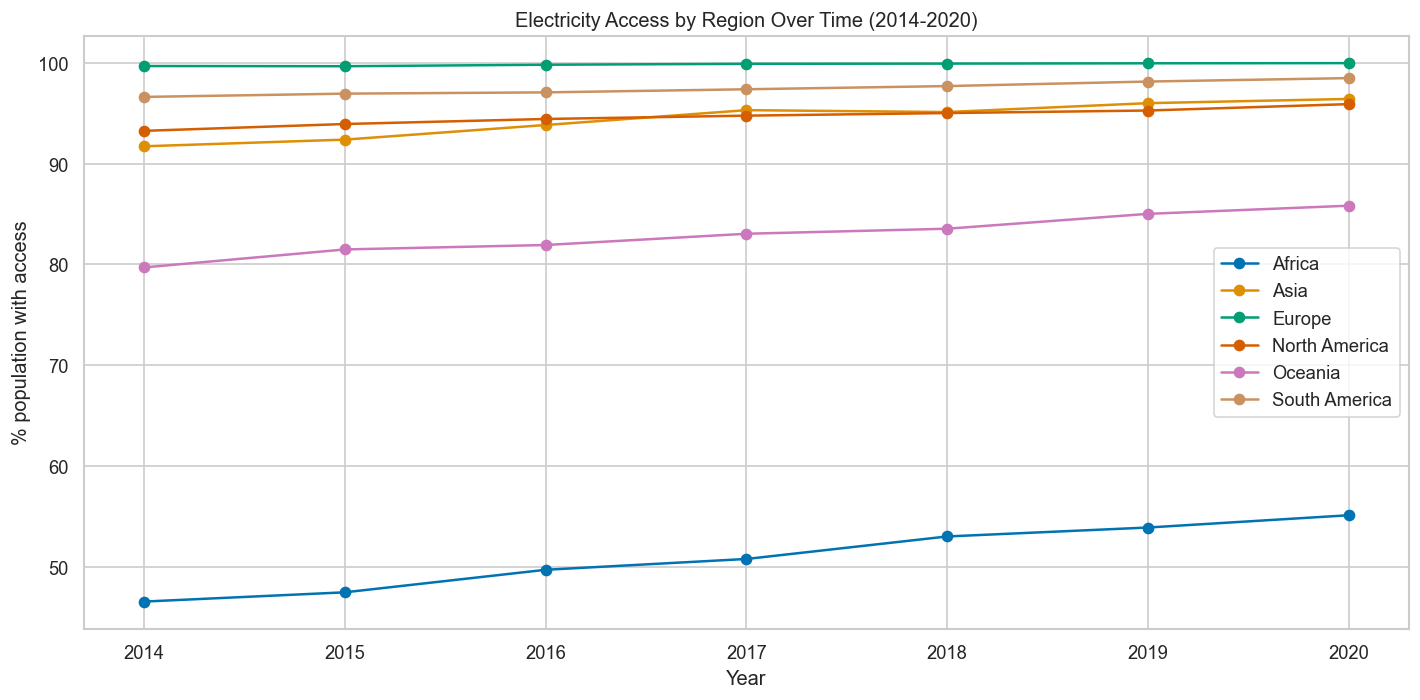

In [21]:
access_time = df.groupby(['region', 'year'])['prct_access_elec'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

for region in access_time['region'].unique():
    subset = access_time[access_time['region'] == region]
    ax.plot(subset['year'], subset['prct_access_elec'], marker='o', label=region)

ax.set_title('Electricity Access by Region Over Time (2014-2020)')
ax.set_ylabel('% population with access')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'h3_access_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Evolution of Total CO2 Emissions by Region Over Time

Tracking whether total emissions are rising or falling across regions — and which regions are driving global emission trends.

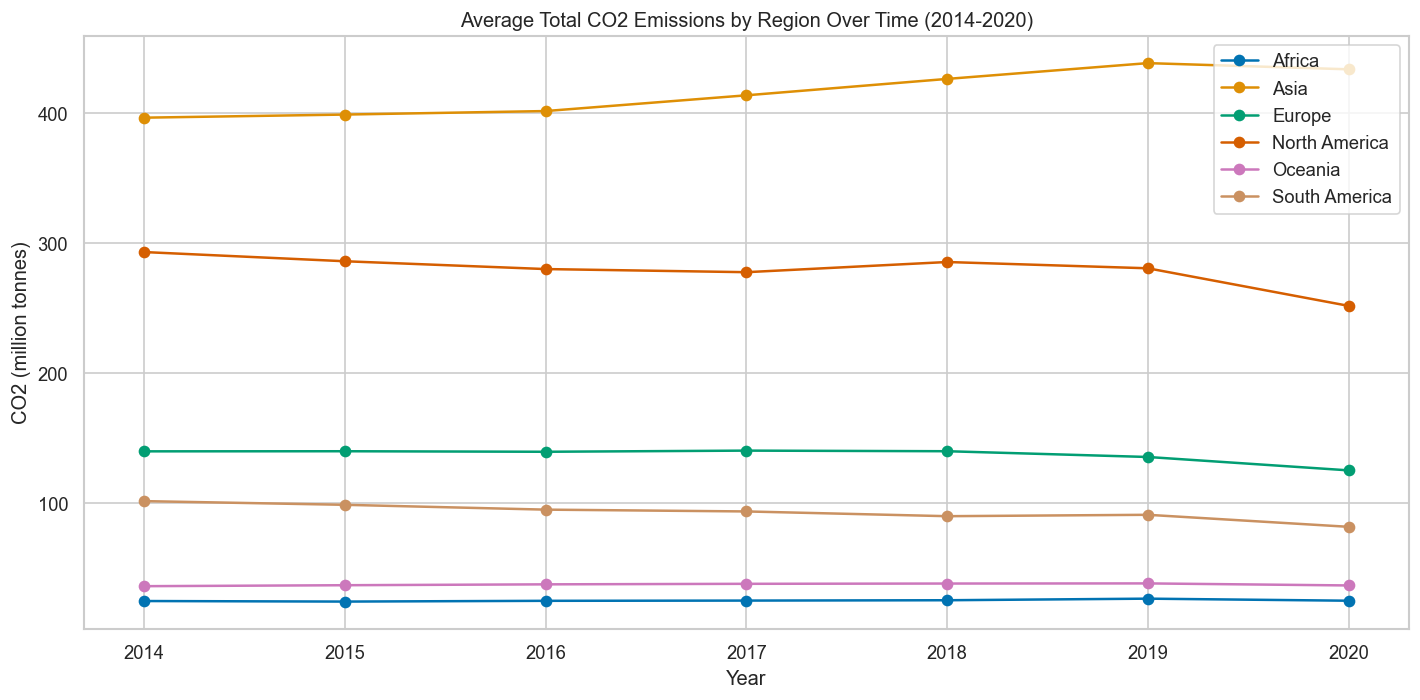

In [22]:
co2_time = df.groupby(['region', 'year'])['co2'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

for region in co2_time['region'].unique():
    subset = co2_time[co2_time['region'] == region]
    ax.plot(subset['year'], subset['co2'], marker='o', label=region)

ax.set_title('Average Total CO2 Emissions by Region Over Time (2014-2020)')
ax.set_ylabel('CO2 (million tonnes)')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'h3_co2_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Top 10 Countries: Evolution of CO2 vs Electricity Access Over Time

Focusing on the most relevant countries from the high-emissions, low-access group identified in EDA — tracking whether their access improved relative to their emissions over the period.

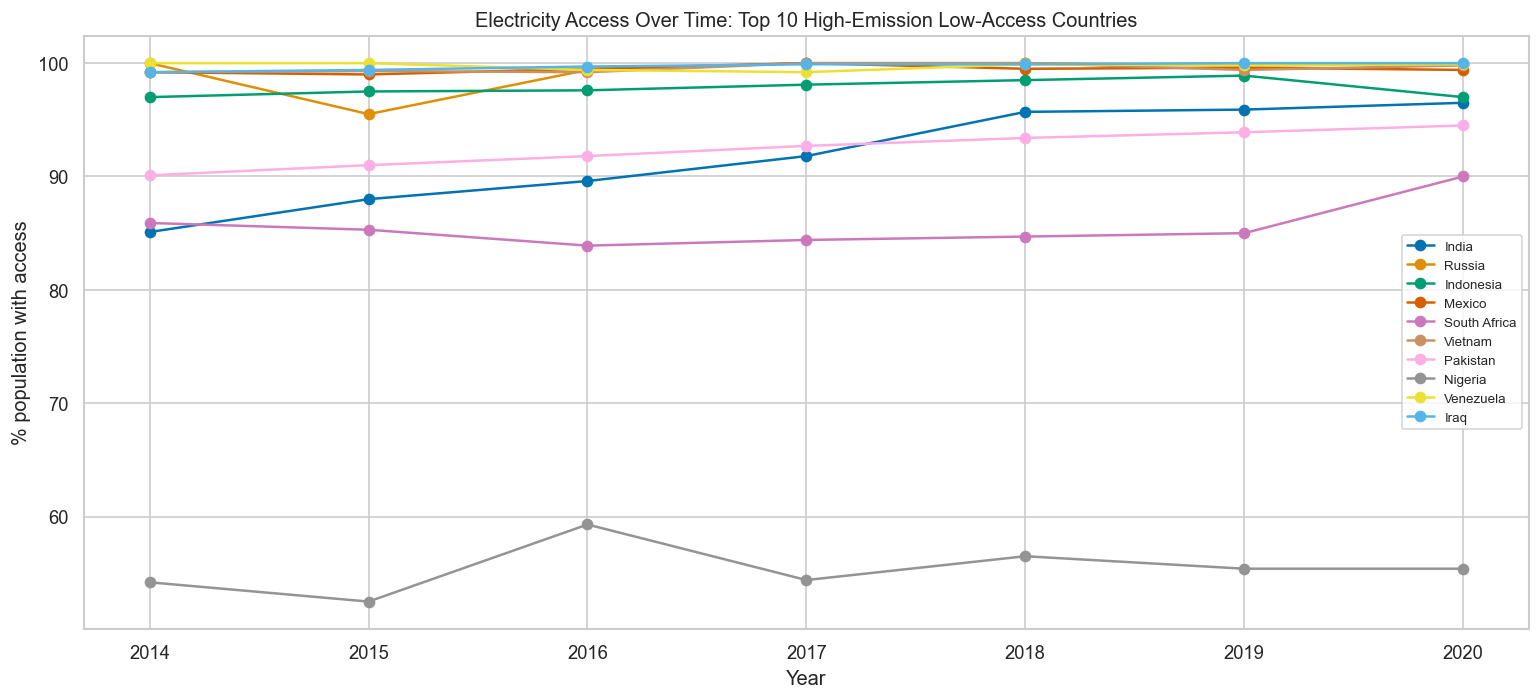

In [23]:
# Top 10 high C02 emission low access countries identified in EDA
top_countries = ['India', 'Russia', 'Indonesia', 'Mexico', 'South Africa',
                 'Vietnam', 'Pakistan', 'Nigeria', 'Venezuela', 'Iraq']

df_top = df[df['country'].isin(top_countries)]

# over the years
access_top = df_top.groupby(['country', 'year'])['prct_access_elec'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 6))
for country in top_countries:
    subset = access_top[access_top['country'] == country]
    ax.plot(subset['year'], subset['prct_access_elec'], marker='o', label=country)

ax.set_title('Electricity Access Over Time: Top 10 High-Emission Low-Access Countries')
ax.set_ylabel('% population with access')
ax.set_xlabel('Year')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'h3_top10_access_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Summary of Findings

### Hypothesis 3 — Key Observations

1. **The wealth-access relationship is confirmed and consistent at regional level** — richer regions have near-universal electricity access, while Africa averages ~50% despite being a globally significant emitter in total.

2. **Mid-income countries (Q3) are the heaviest total emitters** — more than the richest group, suggesting peak industrialisation drives absolute emissions more than wealth itself. However CO2 per capita rises consistently with wealth, meaning richer individuals have larger personal footprints.

3. **The high-emissions, low-access pattern is real and concentrated** — India, Russia, Indonesia, Nigeria and South Africa are the clearest cases of countries generating above-median CO2 while significant portions of their population lack electricity access. This supports the core H3 claim.

4. **Nigeria is the starkest exploitation case** — among the lowest electricity access in the top 15 emitters (~56%), its emissions are clearly not serving its own population.

5. **Electricity access improved across all regions between 2014 and 2020** — but Africa's rate of improvement, while positive, leaves it still far behind all other regions by the end of the period.

### Conclusions

Hypothesis 3 is *partially confirmed*: the wealth-access relationship is clearly supported, and there are real high-CO2/low-access cases, but we would need to add trade/export or industrial-production evidence to confirm it. 

### Limitations

- Total `co2` is influenced by country size and population — large countries like India and Russia will always appear here regardless of efficiency. A per-capita lens tells a different story and should be considered alongside total figures.
- The 2020 COVID dip artificially suppresses emissions in the final year — trend interpretation for that year should be treated with caution.
- Electricity access data from World Bank may lag real conditions by 1–2 years in some African nations due to reporting delays.
  
### Next Steps

